In [161]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from typing import List, Tuple, Dict, Set


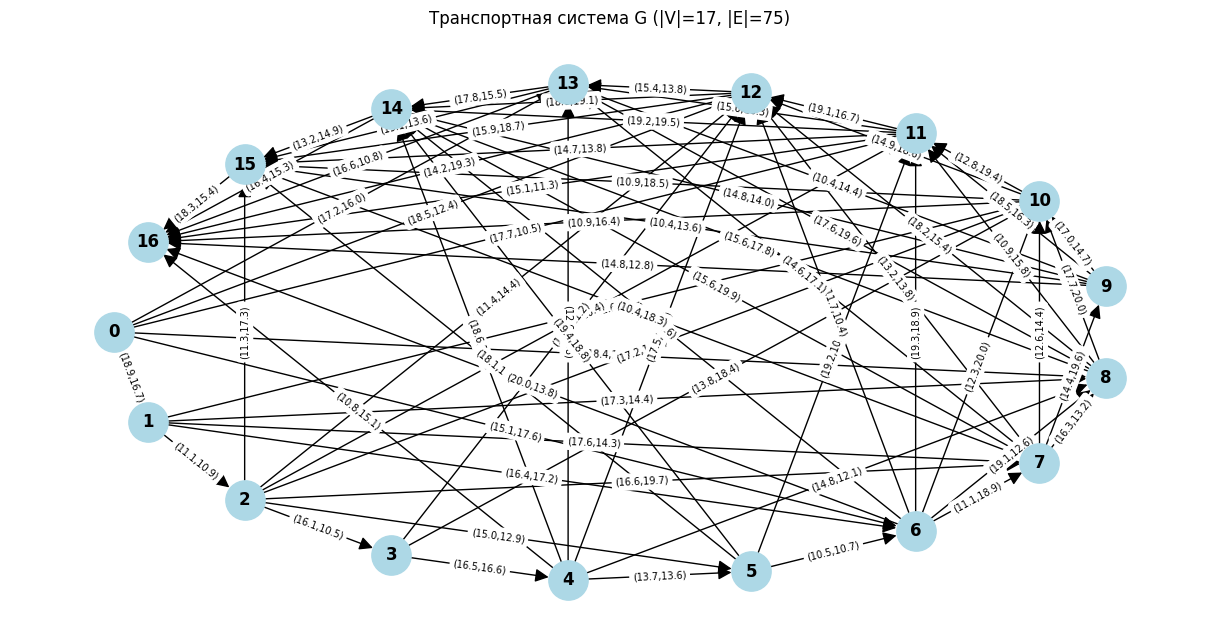

Диаметр графа (самый длинный путь): 15


In [162]:
# Задание 1: Построение и визуализация графа G
def generate_transport_dag(v_count: int = 15, e_min: int = 25) -> nx.DiGraph:
    """
    Генерирует связный ориентированный ациклический граф (DAG).
    Гарантирует диаметр >= 5 путем создания длинного осевого пути.
    """
    G = nx.DiGraph()
    
    # 1. Создаем узлы
    nodes = list(range(v_count))
    G.add_nodes_from(nodes)
    
    # 2. Гарантируем диаметр >= 5 (создаем цепочку 0-1-2-3-4-5-6)
    for i in range(6):
        t = random.uniform(10, 20)
        c = random.uniform(10, 20)
        G.add_edge(i, i+1, t=t, c=c)
        
    # 3. Добавляем остальные ребра до e_min, соблюдая ацикличность (u < v)
    while G.number_of_edges() < e_min:
        u = random.randint(0, v_count - 2)
        v = random.randint(u + 1, v_count - 1)
        if not G.has_edge(u, v):
            t = random.uniform(10, 20)
            c = random.uniform(10, 20)
            G.add_edge(u, v, t=t, c=c)
            
    return G

G = generate_transport_dag(17, 75)
v_start, v_end = 0, 14

# Визуализация графа
plt.figure(figsize=(12, 6))
pos = nx.shell_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=800, arrowsize=20, font_weight='bold')
edge_labels = { (u, v): f"({d['t']:.1f},{d['c']:.1f})" for u, v, d in G.edges(data=True) }
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title(f"Транспортная система G (|V|={G.number_of_nodes()}, |E|={G.number_of_edges()})")
plt.show()

print(f"Диаметр графа (самый длинный путь): {nx.dag_longest_path_length(G)}")

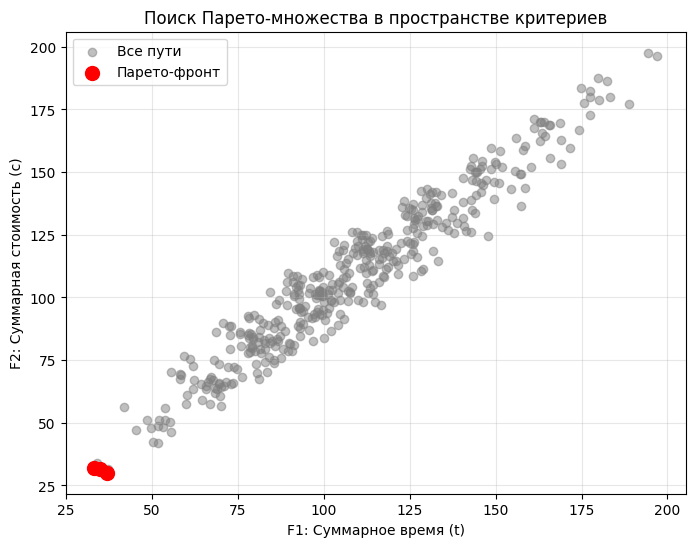

In [163]:
# Задание 2: Поиск Парето-множества
def get_all_paths_costs(graph: nx.DiGraph, start: int, end: int) -> List[Dict]:
    """Находит все пути и их веса."""
    paths_data = []
    for path in nx.all_simple_paths(graph, start, end):
        t_sum = 0
        c_sum = 0
        for i in range(len(path) - 1):
            edge_data = graph[path[i]][path[i+1]]
            t_sum += edge_data['t']
            c_sum += edge_data['c']
        paths_data.append({'path': path, 'F1_t': t_sum, 'F2_c': c_sum})
    return paths_data

def find_pareto_paths(paths_data: List[Dict]) -> List[Dict]:
    """Фильтрует пути, оставляя только Парето-оптимальные."""
    pareto_set = []
    for i, p1 in enumerate(paths_data):
        is_dominated = False
        for j, p2 in enumerate(paths_data):
            if i == j: continue
            # Условие доминирования: p2 лучше p1 по обоим критериям
            if (p2['F1_t'] <= p1['F1_t'] and p2['F2_c'] <= p1['F2_c']) and \
               (p2['F1_t'] < p1['F1_t'] or p2['F2_c'] < p1['F2_c']):
                is_dominated = True
                break
        if not is_dominated:
            pareto_set.append(p1)
    return sorted(pareto_set, key=lambda x: x['F1_t'])

# Вычисления
all_paths = get_all_paths_costs(G, v_start, v_end)
pareto_front = find_pareto_paths(all_paths)

# Визуализация в пространстве критериев
all_f1 = [p['F1_t'] for p in all_paths]
all_f2 = [p['F2_c'] for p in all_paths]
pf_f1 = [p['F1_t'] for p in pareto_front]
pf_f2 = [p['F2_c'] for p in pareto_front]

plt.figure(figsize=(8, 6))
plt.scatter(all_f1, all_f2, c='gray', alpha=0.5, label='Все пути')
plt.step(pf_f1, pf_f2, where='post', c='red', linestyle='--', alpha=0.3)
plt.scatter(pf_f1, pf_f2, c='red', s=100, label='Парето-фронт')
plt.xlabel('F1: Суммарное время (t)')
plt.ylabel('F2: Суммарная стоимость (c)')
plt.title('Поиск Парето-множества в пространстве критериев')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

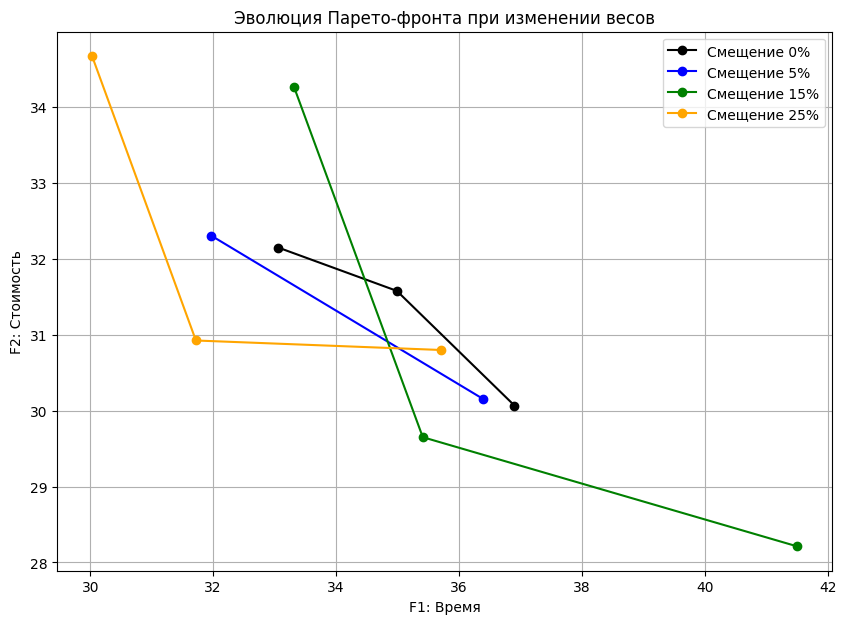

In [164]:
# Задание 3: Изменение весов на 5%, 15%, 25%
def perturb_graph(graph: nx.DiGraph, percentage: float) -> nx.DiGraph:
    """Случайное изменение весов ребер на заданный процент."""
    G_new = graph.copy()
    factor = percentage / 100.0
    for u, v, d in G_new.edges(data=True):
        # Генерируем изменение в диапазоне [-factor, +factor]
        d['t'] *= (1 + random.uniform(-factor, factor))
        d['c'] *= (1 + random.uniform(-factor, factor))
    return G_new

results = {}
for p in [0, 5, 15, 25]:
    G_perturbed = perturb_graph(G, p)
    paths_perturbed = get_all_paths_costs(G_perturbed, v_start, v_end)
    results[p] = find_pareto_paths(paths_perturbed)

# Визуализация изменений
plt.figure(figsize=(10, 7))
colors = {0: 'black', 5: 'blue', 15: 'green', 25: 'orange'}
for p, front in results.items():
    f1 = [x['F1_t'] for x in front]
    f2 = [x['F2_c'] for x in front]
    plt.plot(f1, f2, marker='o', label=f'Смещение {p}%', color=colors[p])

plt.xlabel('F1: Время')
plt.ylabel('F2: Стоимость')
plt.title('Эволюция Парето-фронта при изменении весов')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Количественная сводка
stats = []
for p, front in results.items():
    f1_vals = [x['F1_t'] for x in front]
    f2_vals = [x['F2_c'] for x in front]
    stats.append({
        'Изменение (%)': p,
        'Кол-во точек Парето': len(front),
        'Мин F1': min(f1_vals),
        'Мин F2': min(f2_vals),
        'Размах F1': max(f1_vals) - min(f1_vals)
    })

df_stats = pd.DataFrame(stats)
display(df_stats)

,Изменение (%),Кол-во точек Парето,Мин F1,Мин F2,Размах F1
0,0,3,33.061298,30.068434,3.841382
1,5,2,31.967426,30.153045,4.429683
2,15,3,33.317575,28.213972,8.176495
3,25,3,30.030995,30.800887,5.682207


: 